In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cobid19/non-COVID/Non-Covid (1153).png
/kaggle/input/cobid19/non-COVID/Non-Covid (352).png
/kaggle/input/cobid19/non-COVID/Non-Covid (179).png
/kaggle/input/cobid19/non-COVID/Non-Covid (672).png
/kaggle/input/cobid19/non-COVID/Non-Covid (501).png
/kaggle/input/cobid19/non-COVID/Non-Covid (405).png
/kaggle/input/cobid19/non-COVID/Non-Covid (436).png
/kaggle/input/cobid19/non-COVID/Non-Covid (883).png
/kaggle/input/cobid19/non-COVID/Non-Covid (564).png
/kaggle/input/cobid19/non-COVID/Non-Covid (936).png
/kaggle/input/cobid19/non-COVID/Non-Covid (837).png
/kaggle/input/cobid19/non-COVID/Non-Covid (421).png
/kaggle/input/cobid19/non-COVID/Non-Covid (1031).png
/kaggle/input/cobid19/non-COVID/Non-Covid (221).png
/kaggle/input/cobid19/non-COVID/Non-Covid (1035).png
/kaggle/input/cobid19/non-COVID/Non-Covid (1223).png
/kaggle/input/cobid19/non-COVID/Non-Covid (498).png
/kaggle/input/cobid19/non-COVID/Non-Covid (178).png
/kaggle/input/cobid19/non-COVID/Non-Covid (977).png
/kaggle/

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Conv2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf
from tqdm import tqdm
import time



2025-06-03 14:07:07.184035: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748959627.472965      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748959627.557324      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:

# === CONFIGURATION === #
IMAGE_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 30
N_CLASSES = 2
DATA_DIR = "/kaggle/input/cobid19"

In [4]:
# Image loading and resizing
X = []
Y = []

for label_dir, label in zip(['non-COVID', 'COVID'], [0, 1]):
    path = os.path.join(DATA_DIR, label_dir)
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
            X.append(img)
            Y.append(label)

X = np.array(X) / 255.0
Y = to_categorical(Y, num_classes=N_CLASSES)

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

In [5]:
# === CLASS WEIGHTS (manual tuning) === #
class_weights = {0: 1.0, 1: 1.5}  # Less extreme than 'balanced'

In [6]:
# === IMAGE AUGMENTATION === #
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)
datagen.fit(X_train)

# === MODEL BUILD === #
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

/tmp/ipykernel_13/2966049110.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
2025-06-03 14:07:55.835873: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:

# Fine-tune last layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

input_layer = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(input_layer, training=True)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
out = Dense(N_CLASSES, activation='softmax')(x)

model = Model(input_layer, out)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [8]:

# === CALLBACKS === #
hdf5_save = 'MobileNet_Model.keras'
annealer = ReduceLROnPlateau(monitor='val_accuracy', factor=0.7, patience=5, verbose=1, min_lr=1e-5)
checkpoint = ModelCheckpoint(hdf5_save, monitor='val_accuracy', save_best_only=True, verbose=1)

# === TRAINING === #
start_time = time.time()
history = model.fit(
    datagen.flow(X_train, Y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(X_val, Y_val),
    callbacks=[annealer, checkpoint],
    class_weight=class_weights,
    verbose=1
)
end_time = time.time()

print(f"\nTraining time: {end_time - start_time:.2f} seconds")

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.5467 - loss: 1.4678
Epoch 1: val_accuracy improved from -inf to 0.48893, saving model to MobileNet_Model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 29s 256ms/step - accuracy: 0.5472 - loss: 1.4655 - val_accuracy: 0.4889 - val_loss: 2.3548 - learning_rate: 1.0000e-04
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.6275 - loss: 1.1933
Epoch 2: val_accuracy improved from 0.48893 to 0.53722, saving model to MobileNet_Model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 14s 222ms/step - accuracy: 0.6277 - loss: 1.1925 - val_accuracy: 0.5372 - val_loss: 1.5293 - learning_rate: 1.0000e-04
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.6565 - loss: 1.1201
Epoch 3: val_accuracy improved from 0.53722 to 0.61167, saving model to MobileNet_Model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/step - accuracy: 0.6566 - loss: 1.1200 - val_accuracy: 0.6117 - val_loss: 0.9897 - learning_rate: 1.0000e-04
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step

Classification Report:
              precision    recall  f1-score   support

   Non-COVID       0.80      0.89      0.84       238
       COVID       0.89      0.80      0.84       259

    accuracy                           0.84       497
   macro avg       0.85      0.84      0.84       497
weighted avg       0.85      0.84      0.84       497



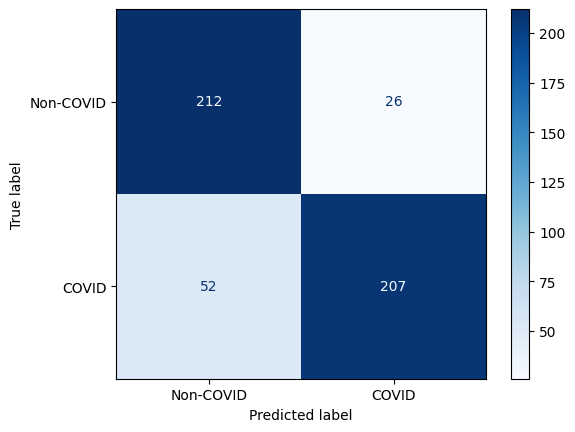

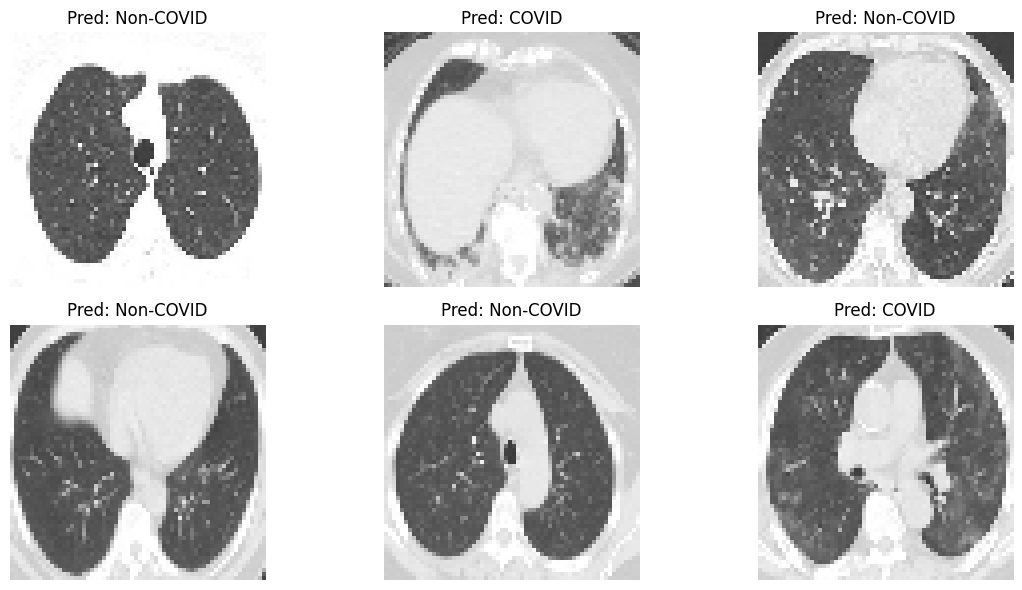

In [9]:
# === EVALUATION === #
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(Y_val, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=['Non-COVID', 'COVID']))

cm = confusion_matrix(y_true, y_pred_classes)
ConfusionMatrixDisplay(cm, display_labels=['Non-COVID', 'COVID']).plot(cmap='Blues')
plt.show()

# === SAMPLE IMAGE PREDICTIONS === #
indices = np.random.choice(np.arange(len(X_val)), size=6, replace=False)
plt.figure(figsize=(12, 6))
for i, idx in enumerate(indices):
    plt.subplot(2, 3, i+1)
    plt.imshow(X_val[idx])
    plt.axis('off')
    plt.title(f"Pred: {'COVID' if y_pred_classes[idx]==1 else 'Non-COVID'}")
plt.tight_layout()
plt.show()

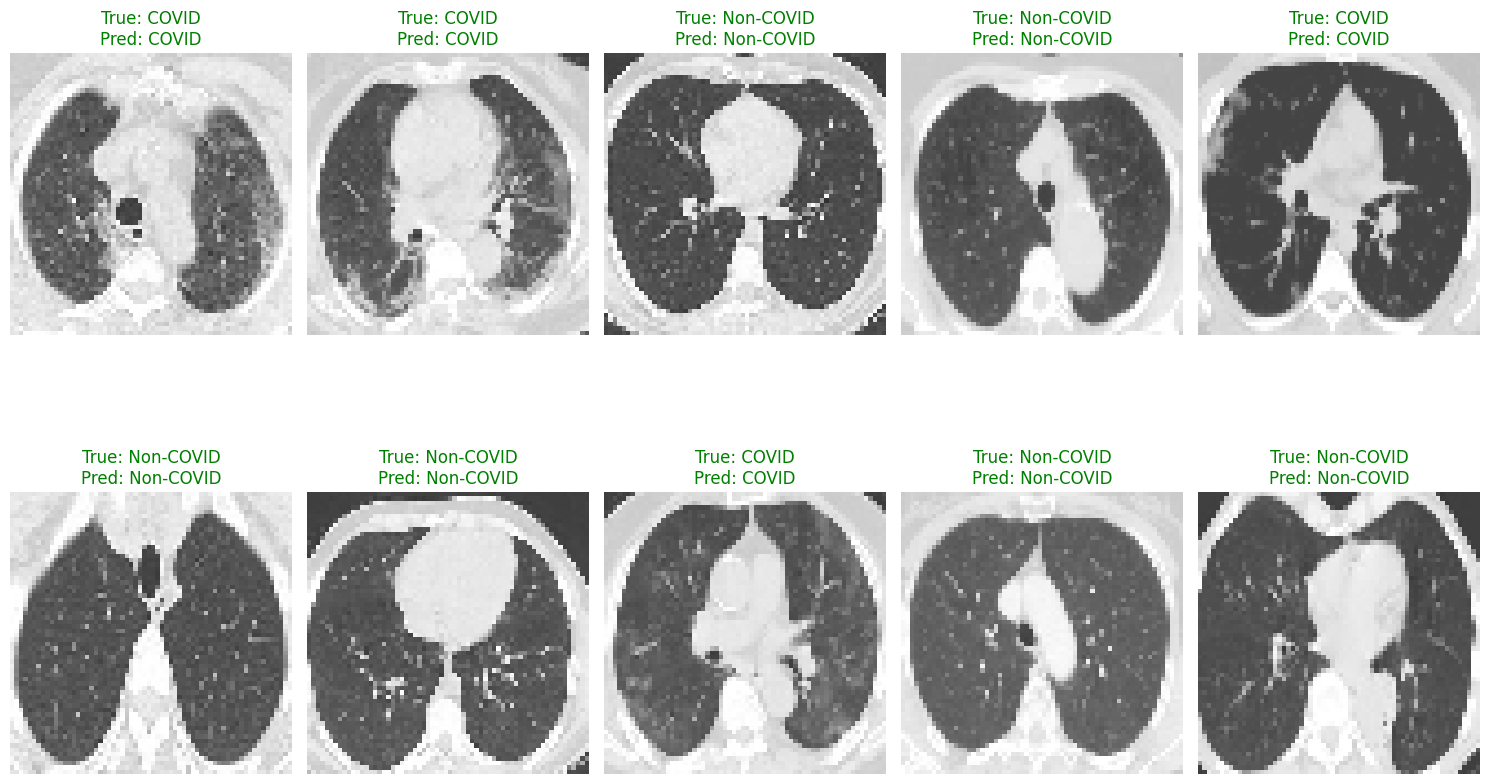

In [10]:
import random

labels = ['Non-COVID', 'COVID']  # Ensure this is defined above the block

plt.figure(figsize=(15, 10))
for i in range(10):
    idx = random.randint(0, len(X_val) - 1)
    img = X_val[idx]
    true_label = labels[y_true[idx]]
    pred_label = labels[y_pred_classes[idx]]  # <-- Corrected from y_pred

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {true_label}\nPred: {pred_label}",
              color='green' if true_label == pred_label else 'red')

plt.tight_layout()
plt.show()


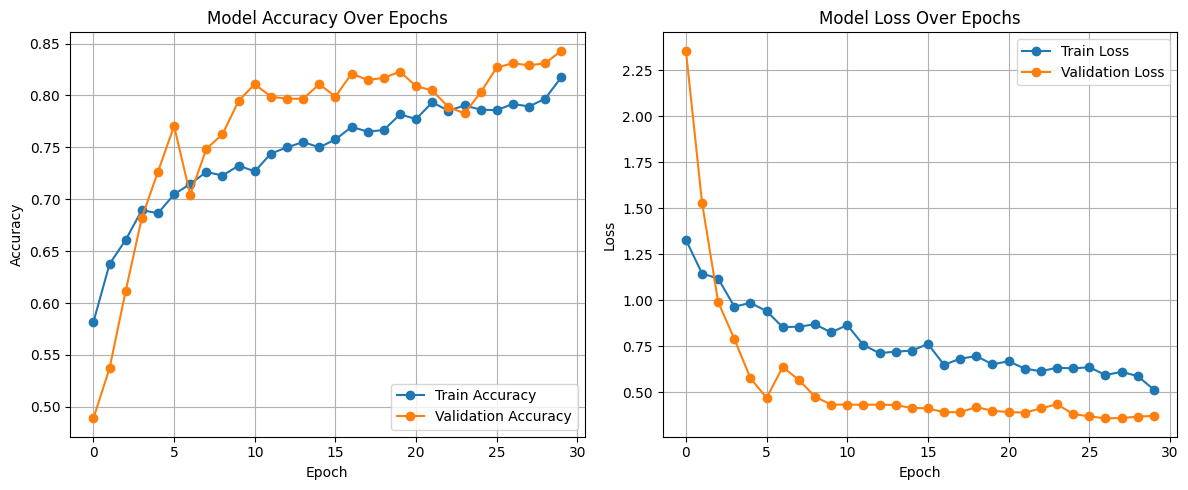

In [11]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


In [12]:
print("Train Accuracy:", max(history.history['accuracy']))
print("Val Accuracy:", max(history.history['val_accuracy']))


Train Accuracy: 0.8175403475761414
Val Accuracy: 0.8430583477020264
